# Azure Learning Journal
[Associate Cloud Engineer, Junior DevOps Engineer, Full-Stack Developer (MERN)]

## The Cloud Landscape

### **1. What is Microsoft Azure?**
Microsoft Azure is a **Public Cloud computing platform** that provides over 200 products and cloud services designed to help innovators to bring new solutions to life. It allows us to build, run, and manage applications across multiple clouds, on-premises, and at the edge, using the tools and frameworks of our choice.

> Global "utility company" for computing power. Instead of buying new servers, we "rent" what we need and pay for what we use.


### 2. Why we choose Azure when AWS is available?

While AWS was the first to market, Azure has unique advantages that make it the preferred choice for many:

* **The Microsoft Ecosystem:** If a company already uses windows server, SQL Server, Active Directory, Microsoft 365, Azure is the natural extension. Integration is "plug-and-play".

* **Hybrid Cloud Leadership:** Azure was built with the "Hybrid" mindset (Connecting on-premises data centers to the cloud) much earlier and more deeply than AWS through tools like Azure Arc.

* **Cost Efficiency for Window/SQL:** Through the **Azure Hybrid Benefits**, companies can reuse their existing on-premises licenses in the cloud, often making Azure upto 5x cheaper than AWS for windows and Sql server workloads.

* **Developer Familiarity**: For developers using .NET, VSCode, or GitHub (Which microsoft owns), the workflow is incredibly smooth.

### **3. Core Benefits of Azure**

| Benefit | Description |
| --- | --- |
| **Scalability** | You can go from 1 user to 1 million users by simply sliding a bar in the portal. |
| **High Availability** | Azure's global network of 60+ regions ensures that even if a data center goes down, your app stays up. |
| **Security & Compliance** | Azure has more compliance certifications (90+) than any other cloud provider, making it the favorite for government and healthcare. |
| **Agility** | Instead of waiting weeks for hardware, you can deploy a full infrastructure in minutes using code or the portal. |


### **4. Comparative Analysis: AWS vs. Azure (2026 Edition)**

| Feature | Amazon Web Services (AWS) | Microsoft Azure |
| --- | --- | --- |
| **Market Identity** | The "Builder's Cloud" (Highly customizable, complex). | The "Enterprise Cloud" (Integrated, user-friendly). |
| **Primary Strength** | Wide variety of specialized services & mature community. | Seamless hybrid cloud & Microsoft software integration. |
| **Networking** | **VPC** (Virtual Private Cloud). | **VNet** (Virtual Network). |
| **Compute** | **EC2** (Elastic Compute Cloud). | **Virtual Machines**. |
| **Storage** | **S3** (Simple Storage Service). | **Blob Storage**. |
| **Identity** | **IAM** (Identity & Access Management). | **Microsoft Entra ID** (Formerly Azure AD). |
| **AI Focus** | Custom ML workflows with SageMaker. | Enterprise-ready AI with Azure OpenAI Service. |

### Visualizing AWS vs. Azure Core Services

This visualization aims to graphically represent the corresponding core services between AWS and Azure, extracted from the comparison table. It uses text annotations and connecting lines to illustrate the mapping.
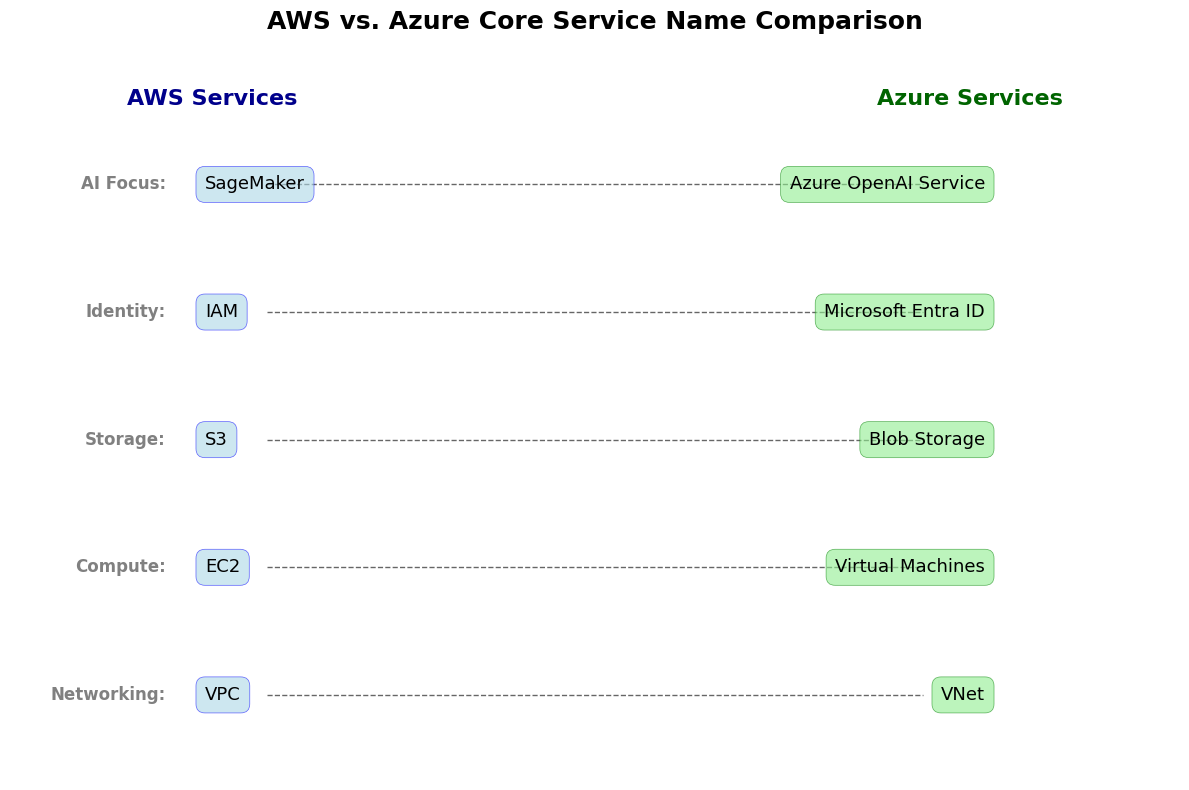


## **Day 1: Secure Access & Identity Management**

### **1. The Core Concept: SSH Key Pairs in Azure**

In the Azure ecosystem, security is a "shared responsibility." Azure provides the infrastructure, but you are responsible for securing access to your resources. For Linux-based Virtual Machines (VMs), **SSH (Secure Shell)** is the industry standard for remote administration.

* **What is it?** A cryptographic network protocol for operating network services securely over an unsecured network.
* **The Mechanism:** It uses **Asymmetric Encryption**.
* **Public Key:** Azure keeps this. It acts like a digital lock on your VM.
* **Private Key:** You keep this. It is the only "key" that can open that specific lock.



### **2. Technical Deep Dive: RSA vs. Ed25519**

In Task 1, you specifically used the **RSA** type.

* **RSA (Rivest–Shamir–Adleman):** The most widely used asymmetric algorithm. In Azure, the default is a **2048-bit** key length. It is based on the mathematical difficulty of factoring the product of two large prime numbers.
* **Why RSA?** It is compatible with almost every legacy system and modern cloud image, making it the safest choice for a "migration strategy" like the Nautilus project.

### **3. Anatomy of the Azure Resource: `datacenter-kp`**

When you create an SSH key in the portal, you aren't just generating a file; you are creating a **Top-level Azure Resource**.

* **Resource Provider:** `Microsoft.Compute/sshPublicKeys`
* **Scope:** This resource is bound to a **Region** (e.g., East US) and a **Resource Group**.
* **Benefit:** Because it is a resource, you can apply **RBAC (Role-Based Access Control)** to it. You can decide which team members are allowed to use this specific key to deploy VMs.


### **4. Step-by-Step Implementation Guide**

| Step | Action | Why? |
| --- | --- | --- |
| **01** | Search for **"SSH Keys"** | Navigates to the specialized management blade for security credentials. |
| **02** | Select **Resource Group** | Logical grouping ensures the key is deleted if the project ends, preventing "resource sprawl." |
| **03** | Name: **`datacenter-kp`** | Standardized naming conventions are vital for DevOps teams to identify production keys. |
| **04** | Select **RSA** | Ensures maximum compatibility across various Linux distributions during migration. |
| **05** | **Download .pem** | **Critical:** Azure does not store the private key. If you don't download it now, the resource is useless for login. |


### **5. Troubleshooting & Best Practices**

* **Permission Denied (Local):** On Linux or Mac, your private key must have restricted permissions to work. You usually need to run `chmod 400 datacenter-kp.pem`.
* **Lost Keys:** If you lose the private key, Azure allows you to "Reset Password/SSH Key" via the VM's "Support + Troubleshooting" blade, but this requires the VM agent to be healthy.
* **Security:** Never commit your `.pem` file to a Git repository. Use a tool like **Azure Key Vault** for long-term secure storage.

## **Day 2: Create an Azure Virtual Machine**

## **Module 2: Compute & Virtual Machines (VM)**

### **1. The Core Concept: Infrastructure as a Service (IaaS)**

A VM is the purest form of **IaaS**. You aren't just renting a server; you're renting a "slice" of a massive physical server in an Azure data center.

* **The Image:** Think of this as the "Snapshot" of the OS. **Ubuntu 24.04 LTS** is the latest "Long Term Support" version, ensuring your server gets security updates until 2029.
* **The Size (`Standard_B1s`):** This belongs to the "Burstable" series. It’s perfect for low-traffic tasks (like learning) because it’s cost-effective and saves "credits" when the CPU is idle.

### **2. Technical Specifications breakdown**

| Requirement | Value | Why? |
| --- | --- | --- |
| **Region** | `westus` | Choosing the right region affects latency and cost. |
| **VM Name** | `devops-vm` | Clear naming helps DevOps teams track resources in a "Resource Group." |
| **Image** | `Ubuntu 24.04 LTS` | The industry-standard Linux distro for developers. |
| **Size** | `Standard_B1s` | 1 vCPU, 1 GiB RAM. The "Student/Free Tier" favorite. |
| **Disk Type** | `Standard HDD` | Magnetic drives. Slowest but cheapest; good for non-production boot disks. |
| **Network (NSG)** | `Port 22` | The "door" for SSH. Without this rule, the VM is a black hole—you can't talk to it. |


### **3. Implementation Guide: Creating your VM**

1. **Search**: Type **"Virtual Machines"** in the Azure Portal search bar.
2. **Basics Tab**:
* **Resource Group**: Use the one you created in Task 1.
* **VM Name**: `devops-vm`
* **Region**: `(US) West US`
* **Image**: Select `Ubuntu Server 24.04 LTS - x64 Gen2`.
* **Size**: Click "See all sizes" and search for `Standard_B1s`.


3. **Administrator Account**:
* **Authentication type**: Select **SSH public key**.
* **Username**: Keep the default (e.g., `azureuser`).
* **SSH public key source**: Select **Use existing key stored in Azure**.
* **Stored Key**: Select **`datacenter-kp`** (from Task 1).


4. **Disks Tab**:
* **OS disk type**: Change from "Premium SSD" to **Standard HDD**.
* **Size**: Ensure it says **30 GiB** (this is usually the default for Linux).


5. **Networking Tab**:
* **Inbound port rules**: Select **Allow selected ports**.
* **Select inbound ports**: Ensure **SSH (22)** is checked.


6. **Review + Create**: Click through to the end and hit **Create**.


### **4. Verification: How to SSH into your VM**

Once the deployment says "Complete," click **Go to resource**. Find the **Public IP address** (e.g., `20.123.45.67`).

Open your terminal (Command Prompt, PowerShell, or Git Bash) and type:

```bash
ssh -i /path/to/your/datacenter-kp.pem azureuser@<Your-Public-IP>
```

* *Note: If you get a "Permissions too open" error on Linux/Mac, run `chmod 400 datacenter-kp.pem` first.*


### **Knowledge Check**

**Look at the "Networking" tab of your VM in the portal. Under "Inbound port rules," you see a "Priority" number for your SSH rule. <br> <br> What does this number mean, and what happens if you add another rule with a lower number that "Denies" all traffic?** <br>
In Azure Network Security Groups (NSGs), each rule has a **priority number** that determines its evaluation order. Here's how it works:

### What the Priority Number Means
- Azure processes NSG rules **from lowest to highest priority**.
- The **lower the number**, the **higher the precedence**.
- For example:
  - Rule A: Priority 100 → evaluated before
  - Rule B: Priority 200

### What Happens If You Add a Lower-Priority "Deny All" Rule
If you add a rule like:
```plaintext
Priority: 100
Action: Deny
Direction: Inbound
Protocol: Any
Source/Destination: Any
```
Then:
- This rule will **block all inbound traffic**, including SSH (port 22).
- Even if you have a rule with Priority 300 that **allows SSH**, it will be ignored because the Deny rule is evaluated first.

### Best Practice
- Always place **specific Allow rules** (like SSH on port 22) **before** any broad Deny rules.
- Example:
  - Priority 100: Allow SSH (port 22)
  - Priority 200: Deny all other inbound traffic

### Related Video

[**Create a Linux Virtual Machine in the Azure Portal**](https://www.youtube.com/watch?v=EZL07vLva5E) <br>
This video walks through the exact portal interface you'll use, helping you visualize where to select the specific size and disk requirements for your DevOps VM.

## **Day 3: Create Azure VM using Azure CLI**

## Task:
**Scenario:** Deploy a virtual machine via the command line when portal access is unavailable.

**Requirements:**

* **Name:** `datacenter-vm`
* **OS Image:** `Ubuntu2204`
* **Size:** `Standard_B2s`
* **Admin:** `azureuser` (with auto-generated SSH keys)
* **Storage:** 30GB, `Standard_LRS` state


### **Step 1: Authenticate and Set Resource Group**

Verify your Azure connection and define the resource group variable to keep the creation command clean.


```bash
# Verify login status (optional if already authenticated via managed identity/service principal)
az account show
```
```
# Define your resource group name (Replace 'YourResourceGroupName' with the actual name)
RG_NAME="YourResourceGroupName"
```

### **Step 2: Execute VM Creation**

Run the single CLI command to provision the compute instance, configure networking, and generate the SSH key pair simultaneously.

```bash
az vm create \
  --resource-group $RG_NAME \
  --name datacenter-vm \
  --image Ubuntu2204 \
  --size Standard_B2s \
  --admin-username azureuser \
  --generate-ssh-keys \
  --os-disk-size-gb 30 \
  --storage-sku Standard_LRS
```

### **Step 3: Verify Running State**

Confirm the provisioning was successful and the VM is in the exact required state.

```bash
# Query the power state of the newly created VM
az vm show \
  --resource-group $RG_NAME \
  --name datacenter-vm \
  --show-details \
  --query "powerState" \
  --output tsv
```

# Expected Output: VM running


## Day 4: Create a Virtual Network (VNet) in Azure

### **Module 3: Foundational Networking (VNet)**

### **1. The Core Concept: Azure Virtual Network (VNet)**

Before deploying multiple resources (like the VMs from Days 2 and 3), they need a secure environment to communicate with each other, the internet, and on-premises networks. An **Azure Virtual Network (VNet)** is the fundamental building block for your private network in Azure.

Think of a VNet as your own isolated, secure slice of the Azure cloud.

### **2. Technical Specifications**

| Requirement | Value | Explanation |
| --- | --- | --- |
| **Name** | `xfusion-vnet` | Standardized naming for the Nautilus migration phase. |
| **Region** | `eastus` | The geographical data center where the network will reside. |
| **Address Space** | `10.0.0.0/16` | A standard IPv4 CIDR block providing 65,536 private IP addresses. |


### **3. Implementation Guide: Azure CLI Method**

Since you are compiling notes that can be run in a Colab notebook or terminal, the Azure CLI is the most efficient and reproducible method for network creation.

**Step 1: Define Variables**
Set your resource group to keep your commands clean.

```bash
# Replace with your actual resource group name
RG_NAME="YourResourceGroupName"
```

**Step 2: Execute VNet Creation**
Run the following command to provision the Virtual Network with a foundational IPv4 address space.

```bash
az network vnet create \
  --name xfusion-vnet \
  --resource-group $RG_NAME \
  --location eastus \
  --address-prefixes 10.0.0.0/16
```

**Step 3: Verify the Creation**
Confirm the VNet is successfully provisioned and check its provisioning state.

```bash
az network vnet show \
  --name xfusion-vnet \
  --resource-group $RG_NAME \
  --query "provisioningState" \
  --output tsv
```

*(Expected Output: `Succeeded`)*


### **4. Implementation Guide: Azure Portal Method**

If the Nautilus team requires visual confirmation or manual setup through the portal, use these steps:

1. **Search:** Navigate to the Azure Portal search bar, type **Virtual Networks**, and select it.
2. **Initiate:** Click **+ Create**.
3. **Basics Tab:**
* **Subscription:** Select your active subscription.
* **Resource Group:** Select your existing resource group.
* **Virtual network name:** Enter `xfusion-vnet`.
* **Region:** Select `(US) East US`.


4. **IP Addresses Tab:**
* Azure usually populates a default IPv4 address space (e.g., `10.0.0.0/16`). You can leave this default or manually enter a new `/16` or `/24` IPv4 block.
* *(Note: A VNet requires at least one subnet. Azure will automatically create a `default` subnet. Leave this as is for this task).*


5. **Finalize:** Click **Review + create**, wait for the validation check to pass, and click **Create**.

## Day 5: Create a Virtual Network (VNet) in Azure

### **Module 3.1: Foundational Networking (VNet)**

### **1. The Core Concept: Azure Virtual Network (VNet)**

Before deploying multiple resources (like the VMs from Days 2 and 3), they need a secure environment to communicate with each other, the internet, and on-premises networks. An **Azure Virtual Network (VNet)** is the fundamental building block for your private network in Azure.

Think of a VNet as your own isolated, secure slice of the Azure cloud.

### **2. Technical Specifications**

| Requirement | Value | Explanation |
| --- | --- | --- |
| **Name** | `xfusion-vnet` | Standardized naming for the Nautilus migration phase. |
| **Region** | `eastus` | The geographical data center where the network will reside. |
| **Address Space** | `10.0.0.0/24` | A standard IPv4 CIDR block providing ***** private IP addresses. |


### **3. Implementation Guide: Azure CLI Method**

Since you are compiling notes that can be run in a Colab notebook or terminal, the Azure CLI is the most efficient and reproducible method for network creation.

**Step 1: Define Variables**
Set your resource group to keep your commands clean.

```bash
# Replace with your actual resource group name
RG_NAME="YourResourceGroupName"
```

**Step 2: Execute VNet Creation**
Run the following command to provision the Virtual Network with a foundational IPv4 address space.

```bash
az network vnet create \
  --name xfusion-vnet \
  --resource-group $RG_NAME \
  --location south central us \
  --address-prefixes 10.0.0.0/24
```

**Step 3: Verify the Creation**
Confirm the VNet is successfully provisioned and check its provisioning state.

```bash
az network vnet show \
  --name xfusion-vnet \
  --resource-group $RG_NAME \
  --query "provisioningState" \
  --output tsv
```

*(Expected Output: `Succeeded`)*


### **4. Implementation Guide: Azure Portal Method**

If the Nautilus team requires visual confirmation or manual setup through the portal, use these steps:

1. **Search:** Navigate to the Azure Portal search bar, type **Virtual Networks**, and select it.
2. **Initiate:** Click **+ Create**.
3. **Basics Tab:**
* **Subscription:** Select your active subscription.
* **Resource Group:** Select your existing resource group.
* **Virtual network name:** Enter `xfusion-vnet`.
* **Region:** Select `(US) East US`.


4. **IP Addresses Tab:**
* Azure usually populates a default IPv4 address space (e.g., `10.0.0.0/24`). You can leave this default or manually enter a new `/24` IPv4 block.
* *(Note: A VNet requires at least one subnet. Azure will automatically create a `default` subnet. Leave this as is for this task).*


5. **Finalize:** Click **Review + create**, wait for the validation check to pass, and click **Create**.

## Day 6: Create a Subnet in Azure Virtual Network

**Scenario:** The Nautilus DevOps migration requires not just a broad network, but a segmented space (a subnet) to organize and secure specific workloads like virtual machines or databases.

**The Concept:** If a **Virtual Network (VNet)** is an entire office building (`10.0.0.0/16`), a **Subnet** is a specific floor or department within that building (`10.0.0.0/24`). You must create subnets to deploy resources; they cannot live in the VNet directly.

**Requirements:**

* **VNet Name:** `xfusion-vnet`
* **Subnet Name:** `xfusion-subnet`
* **Region:** `centralus`
* **VNet IPv4 CIDR:** `10.0.0.0/16`

### **Step 1: Set Up Environment Variables**

Define your target resource group to keep the execution commands clean and reusable.

```bash
# Define your resource group name (Replace 'YourResourceGroupName' with your actual Azure Resource Group)
RG_NAME="YourResourceGroupName"
```

### **Step 2: Create the VNet and Subnet**

The Azure CLI allows you to provision the Virtual Network and its initial Subnet in a single, streamlined command. While the VNet takes the massive `/16` block (65,536 addresses), we will assign a `/24` block (256 addresses) to the subnet, which is standard practice.

```bash
az network vnet create \
  --resource-group $RG_NAME \
  --location centralus \
  --name xfusion-vnet \
  --address-prefixes 10.0.0.0/16 \
  --subnet-name xfusion-subnet \
  --subnet-prefixes 10.0.0.0/24
```

### **Step 3: Verify the Provisioning State**

It is critical for a Cloud Engineer to validate that the infrastructure was successfully deployed and the subnet is attached correctly.

```bash
# Query the subnet to ensure it exists and was provisioned successfully
az network vnet subnet show \
  --resource-group $RG_NAME \
  --vnet-name xfusion-vnet \
  --name xfusion-subnet \
  --query "provisioningState" \
  --output tsv

# Expected Output: Succeeded
```

## **Day 7: Public IP Address Allocation**

**Scenario:** As part of the incremental migration for the Nautilus DevOps team, certain resources will require external internet access. To achieve this, a dedicated Public IP must be provisioned before it is attached to a virtual machine or load balancer.

**The Concept:** A Public IP (PIP) address is an independent Azure resource that provides inbound and outbound internet connectivity. Without it, your Azure resources are strictly isolated within their Virtual Network.

**Requirements:**

* **Resource Name:** `devops-pip`

### **Step 1: Set Up Environment Variables**

Always define your target resource group first to keep your execution commands clean and ensure the IP address is grouped with your existing migration assets.


```bash
# Define your resource group name (Replace 'YourResourceGroupName' with your actual Azure Resource Group)
RG_NAME="YourResourceGroupName"
```

### **Step 2: Allocate the Public IP**

Use the Azure CLI to provision the Public IP address. While Azure allows for basic/dynamic IPs, specifying a `Standard` SKU with a `Static` allocation is the enterprise best practice, ensuring the IP address never changes upon reboot.


```bash
az network public-ip create \
  --resource-group $RG_NAME \
  --name devops-pip \
  --sku Standard \
  --allocation-method Static
```


### **Step 3: Verify the Provisioning State**

Validate that the IP address was successfully allocated and retrieve the actual numeric IPv4 address assigned by the Azure data center.


```bash
# Query the provisioning state and the assigned IP address
az network public-ip show \
  --resource-group $RG_NAME \
  --name devops-pip \
  --query "{State:provisioningState, IPAddress:ipAddress}" \
  --output table

# Expected Output: State will show 'Succeeded' alongside the newly generated IP address.
```

# Day 8: Attach Managed Disk to Azure Virtual Machine

**Scenario:** The Nautilus datacenter team needs to expand the storage capabilities of a currently running virtual machine by attaching an independently managed data disk.

**The Concept:** In Azure, compute (VMs) and storage (Managed Disks) are decoupled. A Data Disk can be created independently of a VM and attached or detached as needed. This architecture ensures that your critical data persists safely, even if the virtual machine itself is stopped, deallocated, or deleted.

**Requirements:**

* **VM Name:** `datacenter-vm`
* **Disk Name:** `datacenter-disk`
* **Region:** `centralus`


### **Step 1: Set Up Environment Variables**

Define your target resource group to ensure the CLI targets the correct environment where your existing VM and disk reside.


```bash
# Define your resource group name (Replace 'YourResourceGroupName' with your actual Azure Resource Group)
RG_NAME="YourResourceGroupName"
```



### **Step 2: Attach the Managed Disk**

Execute the Azure CLI command to link the existing storage resource to the compute resource. Because the disk and VM already exist, you do not need to specify sizes or SKUs—Azure automatically maps the existing disk to an available Logical Unit Number (LUN) on the VM.


```bash
az vm disk attach \
  --resource-group $RG_NAME \
  --vm-name datacenter-vm \
  --name datacenter-disk
```


### **Step 3: Verify the Attachment and VM State**

As a best practice, always validate that the disk was successfully attached and that the VM has fully completed its initialization and updating cycle before considering the task finished.


```bash
# Query the VM to list attached data disks and confirm the overarching provisioning state
az vm show \
  --resource-group $RG_NAME \
  --name datacenter-vm \
  --query "{ProvisioningState:provisioningState, DataDisks:storageProfile.dataDisks[].name}" \
  --output table

# Expected Output: ProvisioningState should be 'Succeeded', and 'datacenter-disk' should be listed under DataDisks.
```